In [2]:
import sys
from pathlib import Path

# Adding project root to sys.path 
root = Path().resolve().parent 
sys.path.append(str(root))

from config import RAW_DIR, INTERIM_DIR
import pandas as pd

print("RAW_DIR:", RAW_DIR)
print("INTERIM_DIR:", INTERIM_DIR)


RAW_DIR: C:\DataProjects\uh-ds-housing-data\data\raw
INTERIM_DIR: C:\DataProjects\uh-ds-housing-data\data\interim


Loaded 5,944,841 rows
Monthly time series shape: (90, 1)


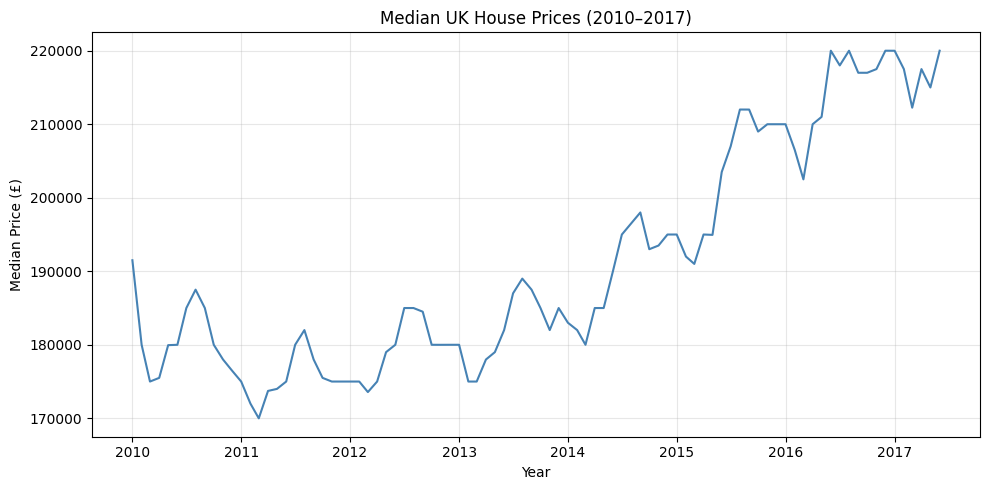

After interpolation: 0 missing values
Train size: 85, Test size: 6


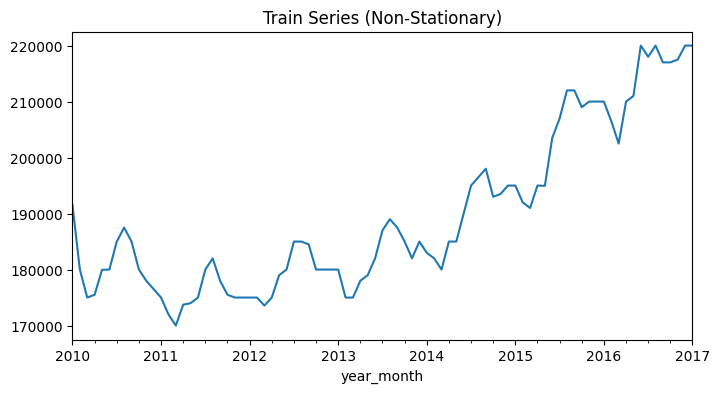

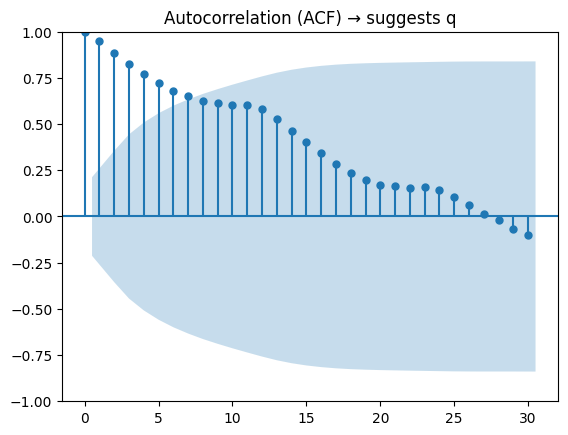

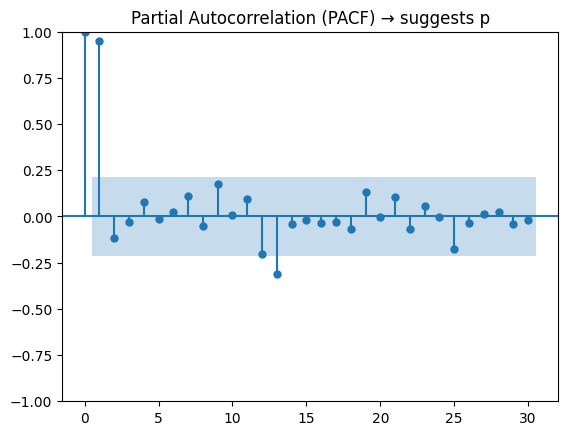

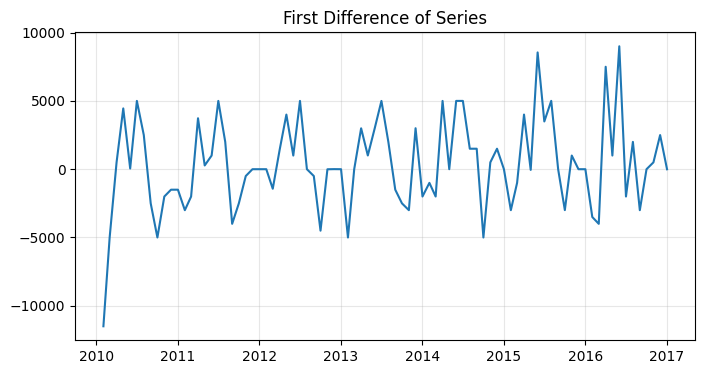

                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                   85
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -795.255
Date:                Tue, 04 Nov 2025   AIC                           1596.510
Time:                        19:59:21   BIC                           1603.803
Sample:                    01-01-2010   HQIC                          1599.442
                         - 01-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2629      0.411      0.639      0.523      -0.543       1.069
ma.L1         -0.3254      0.382     -0.852      0.394      -1.074       0.423
sigma2      9.352e+06   8.04e-09   1.16e+15      0.0

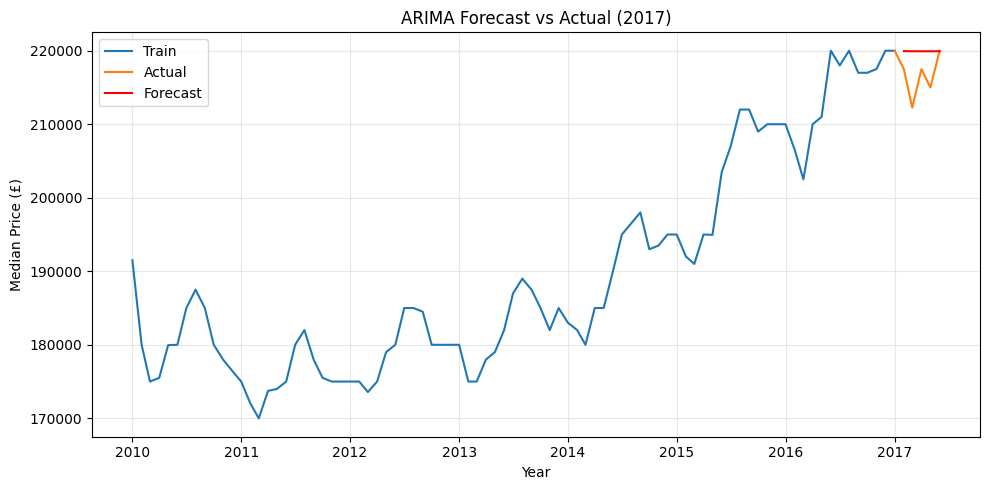

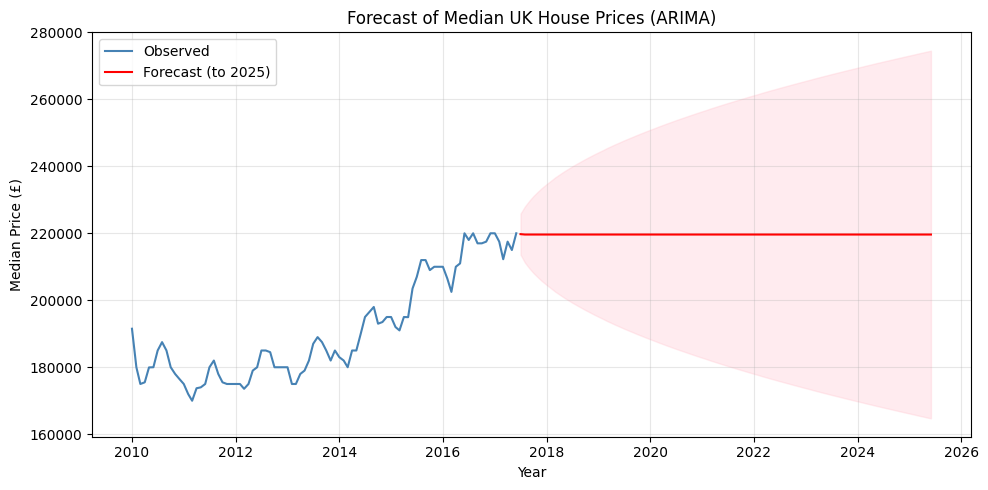

In [7]:
# ARIMA_forecasting.ipynb
# Time Series Forecasting: UK House Prices (ARIMA)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
from config import PROCESSED_DIR

# 1. Load processed data
data_path = PROCESSED_DIR / "uk_housing_2010_2017_processed.csv"
df = pd.read_csv(data_path, parse_dates=["date_of_transfer"], low_memory=False)
print(f"Loaded {len(df):,} rows")

# 2. Aggregate by month
df["year_month"] = df["date_of_transfer"].dt.to_period("M")
monthly = df.groupby("year_month")["price"].median().reset_index()
monthly["year_month"] = monthly["year_month"].dt.to_timestamp()
monthly = monthly.set_index("year_month").asfreq("MS")

print("Monthly time series shape:", monthly.shape)
monthly.head()

# 3. Visualize trend
plt.figure(figsize=(10, 5))
plt.plot(monthly.index, monthly["price"], color="steelblue")
plt.title("Median UK House Prices (2010–2017)")
plt.xlabel("Year")
plt.ylabel("Median Price (£)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Fill missing months by linear interpolation
monthly["price"] = monthly["price"].interpolate(method="linear")
print("After interpolation:", monthly["price"].isna().sum(), "missing values")

# 4. Train-test split (2010–2016 train, 2017 test)
split_date = "2017-01-01"
train = monthly.loc[:split_date]["price"]
test = monthly.loc[split_date:]["price"]

print(f"Train size: {len(train)}, Test size: {len(test)}")

# 5. Check stationarity (visual)
train.plot(figsize=(8, 4), title="Train Series (Non-Stationary)")
plt.show()

# 6. Plot ACF and PACF (to select p, q)
plot_acf(train.dropna(), lags=30)
plt.title("Autocorrelation (ACF) → suggests q")
plt.show()

plot_pacf(train.dropna(), lags=30)
plt.title("Partial Autocorrelation (PACF) → suggests p")
plt.show()

# 7. Differencing (to find d)
diff_series = train.diff().dropna()
plt.figure(figsize=(8,4))
plt.plot(diff_series)
plt.title("First Difference of Series")
plt.grid(alpha=0.3)
plt.show()

# 8. Fit ARIMA Model (manually or auto)
# Example: ARIMA(1,1,1) based on plots (we'll discuss how to pick this)
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()
print(model_fit.summary())

# 9. Forecast
forecast = model_fit.forecast(steps=len(test))
forecast = pd.Series(forecast, index=test.index)

# Evaluate
# --- Evaluate ARIMA forecast safely ---
forecast = pd.Series(forecast, index=test.index)

# Drop any missing values in both actuals and forecast
valid_idx = test.index.intersection(forecast.index)
y_true = test.loc[valid_idx].dropna()
y_pred = forecast.loc[valid_idx].dropna()

# Align indexes again after dropping NaNs
common_idx = y_true.index.intersection(y_pred.index)
y_true, y_pred = y_true.loc[common_idx], y_pred.loc[common_idx]

# Compute metrics
rmse = sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print("\nEvaluation on Test Set (cleaned):")
print(f"RMSE: {rmse:,.2f}")
print(f"MAE : {mae:,.2f}")

# 10. Plot Predictions vs Actual
plt.figure(figsize=(10,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(forecast.index, forecast, label="Forecast", color="red")
plt.title("ARIMA Forecast vs Actual (2017)")
plt.xlabel("Year")
plt.ylabel("Median Price (£)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 11. Extend Forecast to 2025
# -----------------------------
final_model = ARIMA(monthly["price"], order=(0,1,2))
final_fit = final_model.fit()
future_forecast = final_fit.get_forecast(steps=96)  # 8 years monthly
forecast_mean = future_forecast.predicted_mean
forecast_ci = future_forecast.conf_int()

plt.figure(figsize=(10,5))
plt.plot(monthly.index, monthly["price"], label="Observed", color="steelblue")
plt.plot(forecast_mean.index, forecast_mean, label="Forecast (to 2025)", color="red")
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 color="pink", alpha=0.3)
plt.title("Forecast of Median UK House Prices (ARIMA)")
plt.xlabel("Year")
plt.ylabel("Median Price (£)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Loaded 5,944,841 rows
Missing values after interpolation: 0
Train size: 85, Test size: 6

Running auto_ARIMA... (this may take 30–60 seconds)
Performing stepwise search to minimize aic


C:\Users\BALA\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\BALA\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\BALA\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\BALA\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\BALA\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\BALA\a

 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1605.442, Time=0.22 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1596.674, Time=0.15 sec


C:\Users\BALA\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\BALA\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1595.825, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1604.311, Time=0.04 sec


...

C:\Users\BALA\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\BALA\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\BALA\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=1597.826, Time=0.07 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=1599.969, Time=0.23 sec


C:\Users\BALA\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\BALA\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,2)(0,0,0)[0]             : AIC=1596.249, Time=0.06 sec

Best model:  ARIMA(0,1,2)(0,0,0)[0] intercept
Total fit time: 1.494 seconds

Best Model Selected:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   85
Model:               SARIMAX(0, 1, 2)   Log Likelihood                -793.889
Date:                Wed, 19 Nov 2025   AIC                           1595.777
Time:                        13:09:56   BIC                           1605.500
Sample:                    01-01-2010   HQIC                          1599.686
                         - 01-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    316.7132    324.583      0.976  

C:\Users\BALA\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


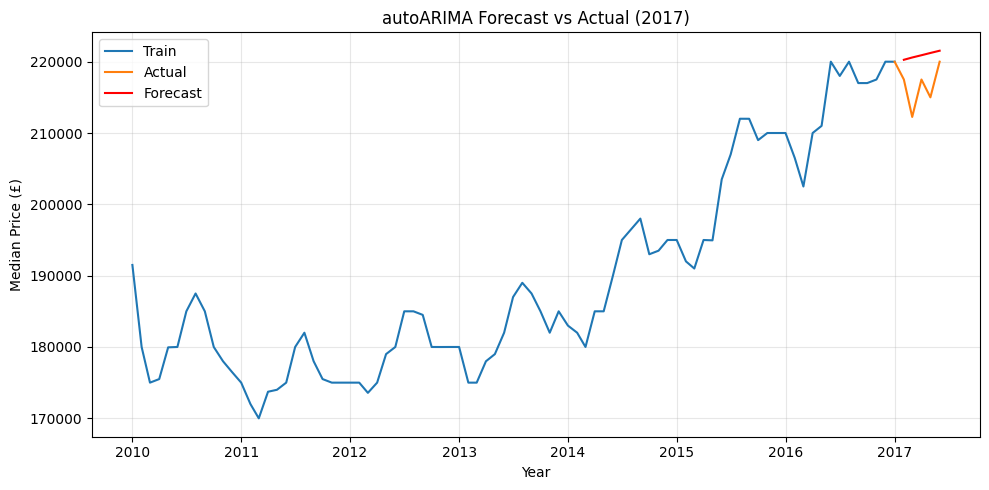

C:\Users\BALA\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\BALA\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\BALA\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


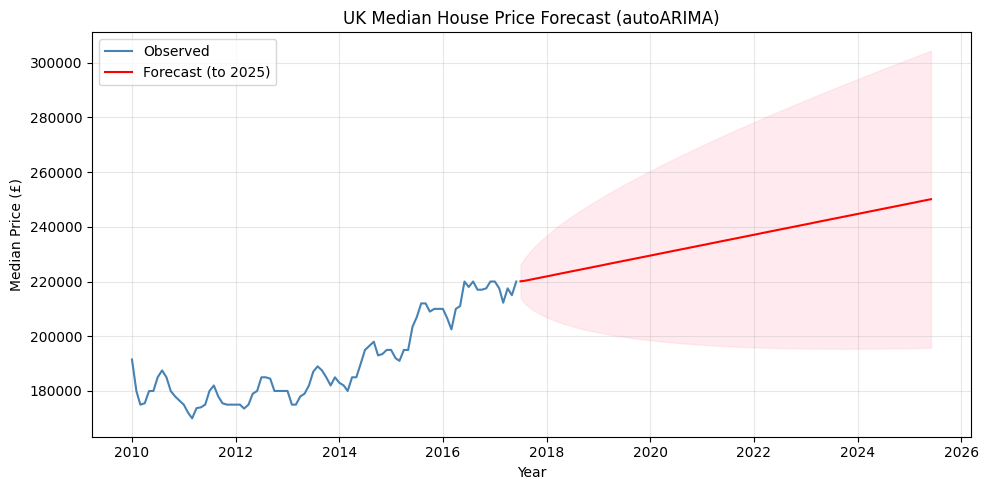


Saved forecast plot to: C:\DataProjects\uh-ds-housing-data\data\reports\figures\autoARIMA_forecast.png


<Figure size 640x480 with 0 Axes>

In [3]:
# =====================================================================
# 09_autoARIMA_forecasting.ipynb
# Automated ARIMA Model Selection and Forecasting
# =====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error
from config import PROCESSED_DIR

# -----------------------------
# 1. Load and prepare dataset
# -----------------------------
data_path = PROCESSED_DIR / "uk_housing_2010_2017_processed.csv"
df = pd.read_csv(data_path, parse_dates=["date_of_transfer"], low_memory=False)
print(f"Loaded {len(df):,} rows")

# Aggregate by month (median price)
df["year_month"] = df["date_of_transfer"].dt.to_period("M")
monthly = df.groupby("year_month")["price"].median().reset_index()
monthly["year_month"] = monthly["year_month"].dt.to_timestamp()
monthly = monthly.set_index("year_month").asfreq("MS")

# Fill missing months with linear interpolation
monthly["price"] = monthly["price"].interpolate(method="linear")
print("Missing values after interpolation:", monthly["price"].isna().sum())

# -----------------------------
# 2. Train-test split
# -----------------------------
split_date = "2017-01-01"
train = monthly.loc[:split_date]["price"]
test = monthly.loc[split_date:]["price"]
print(f"Train size: {len(train)}, Test size: {len(test)}")

# -----------------------------
# 3. Run auto ARIMA
# -----------------------------
print("\nRunning auto_ARIMA... (this may take 30–60 seconds)")
model = auto_arima(
    train,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=None, max_d=2,       # Let it decide differencing
    seasonal=False,        # We'll use non-seasonal first
    stepwise=True,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    random_state=42
)

print("\nBest Model Selected:")
print(model.summary())

# -----------------------------
# 4. Forecast for test period
# -----------------------------
forecast = model.predict(n_periods=len(test))
forecast = pd.Series(forecast, index=test.index)

# Drop any NaNs before evaluation
valid_idx = test.index.intersection(forecast.index)
y_true = test.loc[valid_idx].dropna()
y_pred = forecast.loc[valid_idx].dropna()
common_idx = y_true.index.intersection(y_pred.index)
y_true, y_pred = y_true.loc[common_idx], y_pred.loc[common_idx]

# Evaluate
rmse = sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print("\nEvaluation on Test Set:")
print(f"RMSE: {rmse:,.2f}")
print(f"MAE : {mae:,.2f}")

# -----------------------------
# 5. Plot Predictions vs Actual
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(forecast.index, forecast, label="Forecast", color="red")
plt.title("autoARIMA Forecast vs Actual (2017)")
plt.xlabel("Year")
plt.ylabel("Median Price (£)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 6. Extend Forecast to 2025
# -----------------------------
model.fit(monthly["price"])
future_forecast, conf_int = model.predict(n_periods=96, return_conf_int=True)
future_index = pd.date_range(monthly.index[-1] + pd.offsets.MonthBegin(),
                             periods=96, freq="MS")

forecast_df = pd.DataFrame({
    "Forecast": future_forecast,
    "Lower CI": conf_int[:, 0],
    "Upper CI": conf_int[:, 1]
}, index=future_index)

# -----------------------------
# 7. Plot Extended Forecast
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(monthly.index, monthly["price"], label="Observed", color="steelblue")
plt.plot(forecast_df.index, forecast_df["Forecast"], label="Forecast (to 2025)", color="red")
plt.fill_between(forecast_df.index,
                 forecast_df["Lower CI"],
                 forecast_df["Upper CI"],
                 color="pink", alpha=0.3)
plt.title("UK Median House Price Forecast (autoARIMA)")
plt.xlabel("Year")
plt.ylabel("Median Price (£)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Save results
figures_dir = PROCESSED_DIR.parent / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / "autoARIMA_forecast.png", dpi=300)
print(f"\nSaved forecast plot to: {figures_dir / 'autoARIMA_forecast.png'}")
